In [ ]:
import sys
sys.path.append("../data") 
from archi_dict import archi_sorghum as archi

from plot_outputs import *

from openalea.archicrop.stics_io import stics_output
from openalea.archicrop.simulation import compute_1_growing_plant
from openalea.archicrop.viability import compute_viable_parameter_space

In [ ]:
plant_name = "sorghum"

In [ ]:
tec_file='../data/usms_STICS/v10/02NT18SorgV2D1_tec.xml'
plant_file='../data/usms_STICS/v10/plant/sorgho_imp_M_v10_plt.xml'
stics_output_file='../data/usms_STICS/v10/mod_s02NT18SorgV2D1.sti'
stics_output_file_pot='../data/usms_STICS/v10/mod_s02NT18SorgV2D1_no_stress.sti'

density, daily_dynamics, lifespan, lifespan_early, thermal_time, leaf_area_plant, sen_leaf_area_plant, height_canopy, end_juv, end_veg, index_end_veg = stics_output(tec_file, plant_file, stics_output_file)
density_pot, daily_dynamics_pot, lifespan_pot, lifespan_early_pot, thermal_time_pot, leaf_area_plant_pot, sen_leaf_area_plant_pot, height_canopy_pot, end_juv_pot, end_veg_pot, index_end_veg_pot = stics_output(tec_file, plant_file, stics_output_file_pot)

In [ ]:
phi_bounds = [30,80]
rmax_bounds = [0.5,0.95]
N_bounds = [10,40]

d, N, phi, rmax = compute_viable_parameter_space(N_bounds, phi_bounds, rmax_bounds, thermal_time_pot, leaf_area_plant_pot, index_end_veg_pot, archi, end_veg_corr=3)

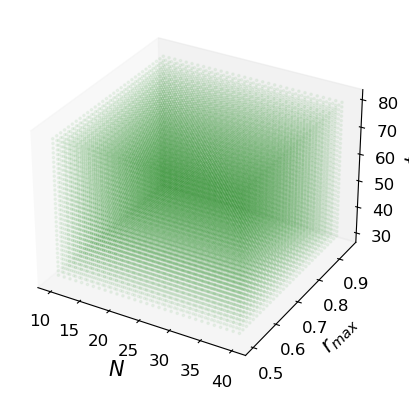

In [ ]:
# Example parameter space
p1 = np.arange(min(N_bounds), max(N_bounds)+1)
p2 = np.linspace(min(rmax_bounds), max(rmax_bounds), len(p1))
p3 = np.linspace(min(phi_bounds), max(phi_bounds), len(p1))

P1, P2, P3 = np.meshgrid(p1, p2, p3)

fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='green', alpha=0.05)

ax.set_xlabel(r"$N$", fontsize=15)
ax.set_ylabel(r"$r_{max}$", fontsize=15)
ax.set_zlabel(r"$\phi$", fontsize=15)
ax.tick_params(labelsize=12)

ax.grid(False)


plt.savefig(f"../figures/morphospace_all.png", dpi=1000)
plt.show()


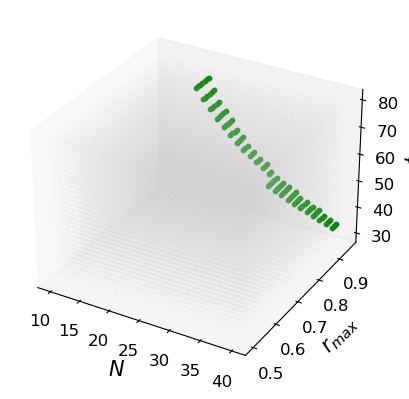

In [ ]:
fig = plt.figure() 
ax = fig.add_subplot(projection='3d')

ax.scatter(P1.ravel(), P2.ravel(), P3.ravel(), s=3, color='lightgrey', alpha=0.05)

end_veg_pot = thermal_time_pot[index_end_veg_pot+1]

for n,l in d.items():
    for p,r in l:
        ax.scatter(
            n, r, p, s=10, c='green', alpha=1
        )

ax.set_xlabel(r"$N$", fontsize=15)
ax.set_ylabel(r"$r_{max}$", fontsize=15)
ax.set_zlabel(r"$\phi$", fontsize=15)
ax.tick_params(labelsize=12)

ax.grid(False)

plt.savefig(f"../figures/morphospace_constrained.png")
plt.show()


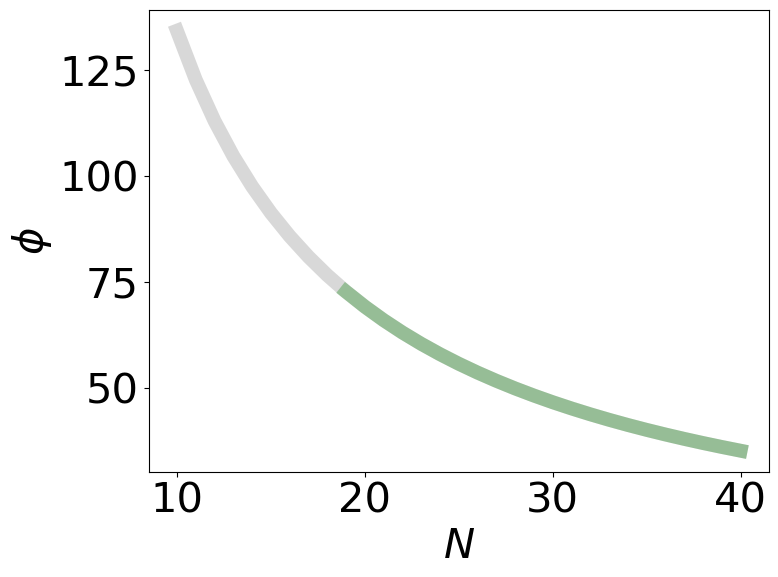

In [ ]:
plot_parameter_space_N_phi(plant_name, d, N, phi)

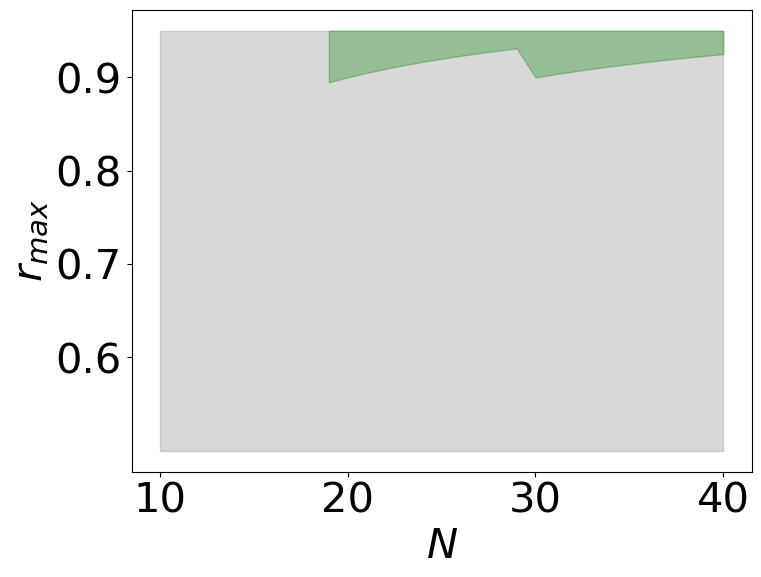

In [ ]:
plot_parameter_space_N_rmax(plant_name, d, N, rmax, rmax_bounds)

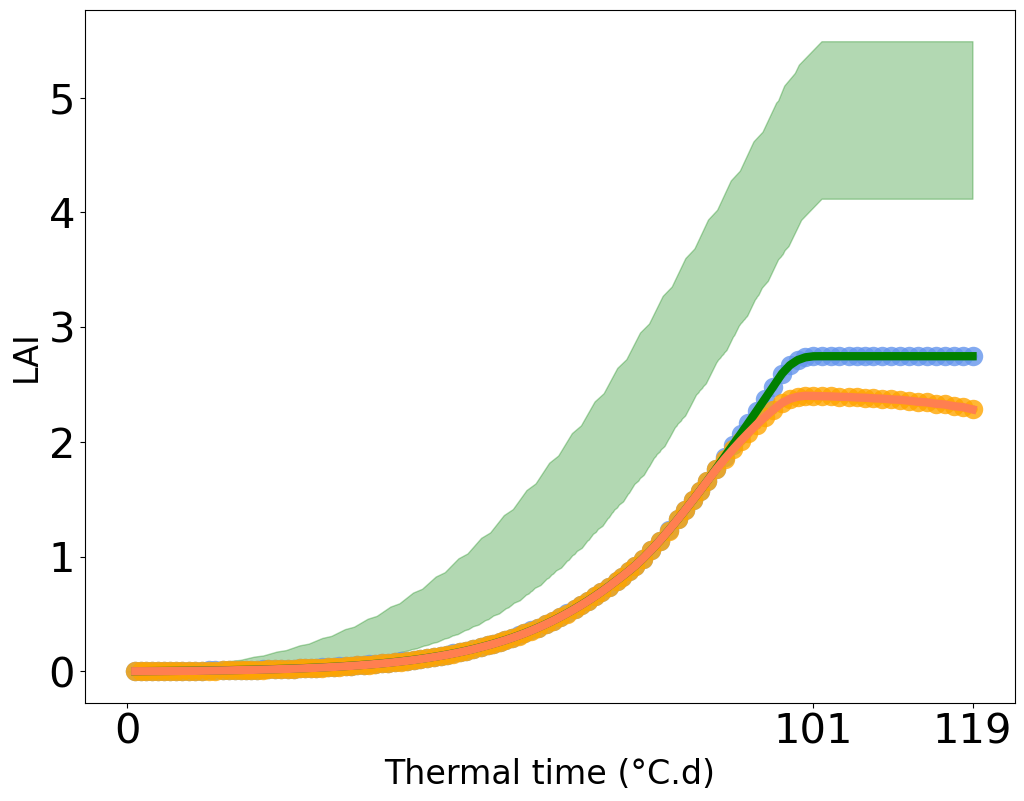

In [ ]:
plot_LAI_and_pot(d, thermal_time, thermal_time_pot, leaf_area_plant, leaf_area_plant_pot, sen_leaf_area_plant, index_end_veg, index_end_veg_pot, end_veg, density, no_stress=True)

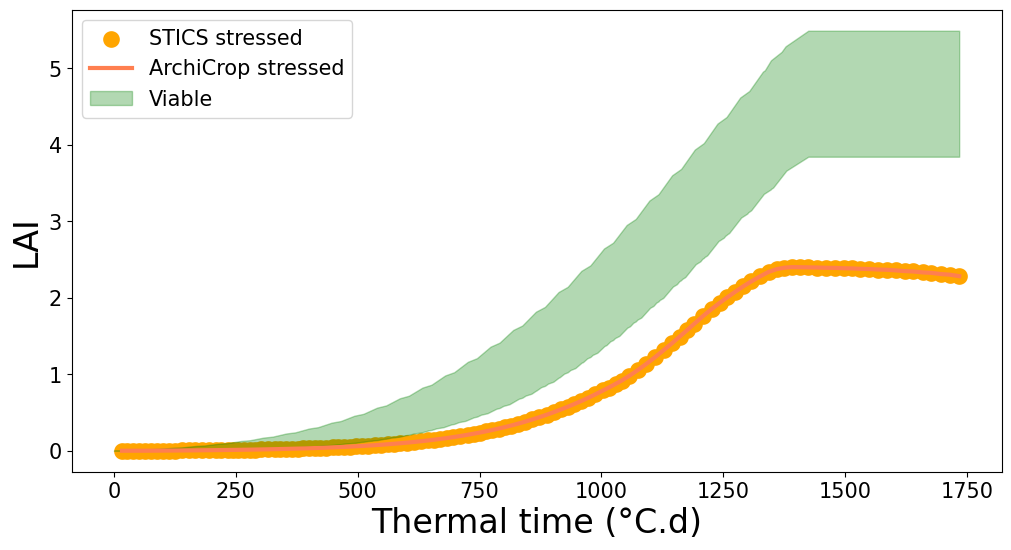

In [ ]:
plot_LAI_and_pot(d, thermal_time, thermal_time_pot, leaf_area_plant, leaf_area_plant_pot, sen_leaf_area_plant, index_end_veg, index_end_veg_pot, end_veg, density, no_stress=False)

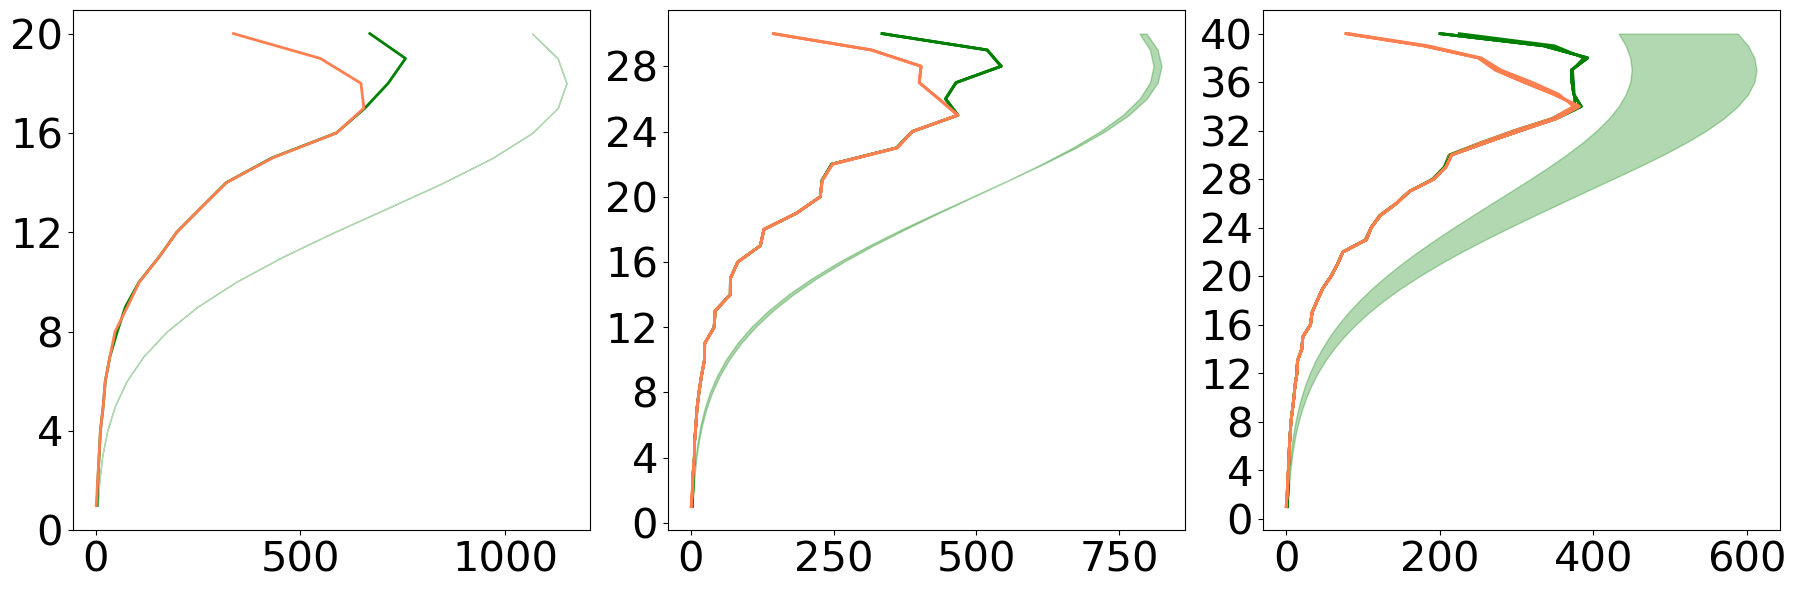

In [ ]:
N_to_display = [20,30,40]
# N_viable = [n for n in d if d[n] != []]
# N_to_display = [min(N_viable), max(N_viable)]
leaf_profiles(plant_name, N_to_display, archi, stics_output_file, stics_output_file_pot, tec_file, plant_file)

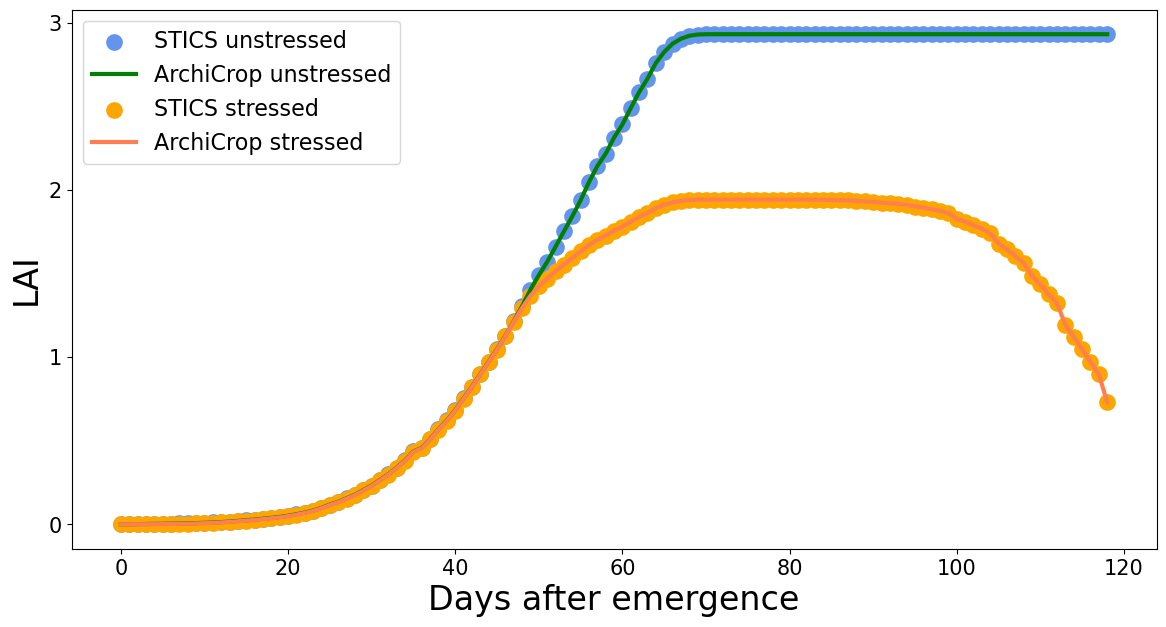

In [ ]:
plot_LAI_stressed_and_not(thermal_time, leaf_area_plant, sen_leaf_area_plant, leaf_area_plant_pot, sen_leaf_area_plant_pot, density)

In [ ]:
growing_plant = compute_1_growing_plant(archi, d, daily_dynamics, leaf_area_plant_pot, height_canopy_pot)

Time for 1 simulation of 119 days: 3.5380165576934814


In [ ]:
from openalea.archicrop.display import build_scene
from openalea.plantgl.all import Color3, Material, Viewer
from openalea.widgets.plantgl import *
%gui qt

m = Material(Color3(0,80,0))

times = [20,30,40,55,70,100,125,150]
mean_time = sum(times) / len(times)
positions = [(6*(t-mean_time), 0, 0) for t in times]
mtgs_list = [g for i,g in growing_plant.items() if i in times]
scene1, _ = build_scene(mtgs_list, position=positions, senescence=True, leaf_material = m, stem_material=m, senescence_material=Material(Color3(70, 60, 0)))
Viewer.display(scene1)